In [10]:
import os

for root, dirs, files in os.walk('/kaggle/input/brain-ct-hemorrhage-dataset'):
    level = root.replace('/kaggle/input/brain-ct-hemorrhage-dataset', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  # don't spam file lists, just show a couple examples
        for f in files[:3]:
            print(f'{indent}  {f}')

In [11]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [12]:
import os
print(os.listdir('/kaggle/input/datasets'))

['abdulkader90']


In [13]:
import os
print(os.listdir('/kaggle/input/datasets/abdulkader90'))

['brain-ct-hemorrhage-dataset']


In [14]:
import os
print(os.listdir('/kaggle/input/datasets/abdulkader90/brain-ct-hemorrhage-dataset'))

['Data']


In [15]:
import os, glob

base = '/kaggle/input/datasets/abdulkader90/brain-ct-hemorrhage-dataset/Data'
print(os.listdir(base))

hem_files = glob.glob(base + '/Hemorrhagic/KANAMA/**/*.[jJ][pP][gG]', recursive=True)
normal_files = glob.glob(base + '/NORMAL/**/*.[jJ][pP][gG]', recursive=True)

print(f"Hemorrhage: {len(hem_files)} (expected 2690)")
print(f"Normal: {len(normal_files)} (expected 4105)")

['NORMAL', 'Hemorrhagic']
Hemorrhage: 2690 (expected 2690)
Normal: 4105 (expected 4105)


In [16]:
import numpy as np, cv2, glob
from sklearn.model_selection import train_test_split

base = '/kaggle/input/datasets/abdulkader90/brain-ct-hemorrhage-dataset/Data'
hem = glob.glob(base + '/Hemorrhagic/KANAMA/**/*.[jJ][pP][gG]', recursive=True)
norm = glob.glob(base + '/NORMAL/**/*.[jJ][pP][gG]', recursive=True)

def load(files):
    return [cv2.resize(cv2.imread(f, 0), (224,224)) for f in files if cv2.imread(f, 0) is not None]

X = np.array(load(hem) + load(norm), dtype=np.uint8)
y = np.array([1]*len(hem) + [0]*len(norm), dtype=np.uint8)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train = (X_train.astype('float32')/255.0).reshape(-1,224,224,1)
X_test = (X_test.astype('float32')/255.0).reshape(-1,224,224,1)

print(X_train.shape, X_test.shape)

(5436, 224, 224, 1) (1359, 224, 224, 1)


In [17]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-09 16:48:22.872476: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.8738 - loss: 0.2682 - val_accuracy: 0.9875 - val_loss: 0.0449
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.9864 - loss: 0.0381 - val_accuracy: 0.9993 - val_loss: 0.0094
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9934 - loss: 0.0173 - val_accuracy: 0.9978 - val_loss: 0.0048
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9960 - loss: 0.0155 - val_accuracy: 0.9985 - val_loss: 0.0031
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9987 - loss: 0.0036 - val_accuracy: 0.9993 - val_loss: 0.0020


In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 401ms/step - accuracy: 0.9993 - loss: 0.0020
Test accuracy: 0.9993, Test loss: 0.0020


43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 402ms/step


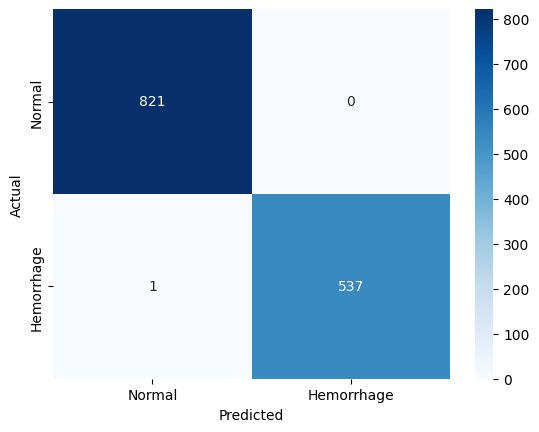

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       821
  Hemorrhage       1.00      1.00      1.00       538

    accuracy                           1.00      1359
   macro avg       1.00      1.00      1.00      1359
weighted avg       1.00      1.00      1.00      1359



In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Hemorrhage'], yticklabels=['Normal','Hemorrhage'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Normal','Hemorrhage']))

In [21]:
model.save('hemorrhage_cnn_model.h5')
# or the newer Keras format:
# model.save('hemorrhage_cnn_model.keras')